# Embedded Method With SMOTE-ENN

## Import Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from sklearn.pipeline import Pipeline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from imblearn.combine import SMOTEENN
from sklearn.model_selection import train_test_split , GridSearchCV , KFold
from sklearn.linear_model import Lasso, LassoCV
from sklearn.feature_selection import SelectKBest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, make_scorer, confusion_matrix, log_loss
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC

## Import Data

In [2]:
# Import  the SPSS data file
df=pd.read_spss("E:\Data Analysis\BDHS_2017-2018.sav")
# Displaying the first 5 rows of the DataFrame
df.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,BMI2
0,15-19,Rajshahi,Rural,Secondary,No education,Islam,Male,No child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Modern methods,Underweight/Normal
1,45-49,Rangpur,Urban,Primary,No education,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Traditional methods,Underweight/Normal
2,15-19,Khulna,Rural,Secondary,Primary,Islam,Male,One child,No,No,...,Poorer,Poorer,Improved,Improved,Solid fuel,No or unsure,Yes,Respondent and husband/partner,Modern methods,Underweight/Normal
3,40-44,Barisal,Urban,Primary,Primary,Islam,Male,More than two child,No,No,...,Poorest,Poorest,Improved,Improved,Solid fuel,No or unsure,No,Respondent and husband/partner,Not using,Underweight/Normal
4,25-29,Barisal,Rural,Secondary,Higher,Islam,Male,One child,No,No,...,Richer,Richest,Improved,Improved,Solid fuel,Yes,No,Respondent and husband/partner,Not using,Underweight/Normal


## Get some Basic Information

In [3]:
# Displaying a summary of the DataFrame, including the number of non-null entries and data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16303 entries, 0 to 16302
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   V013    16303 non-null  category
 1   V024    16303 non-null  category
 2   V025    16303 non-null  category
 3   V106    16303 non-null  category
 4   V701    16303 non-null  category
 5   V130    16303 non-null  category
 6   V151    16303 non-null  category
 7   V201    16303 non-null  category
 8   V123    16303 non-null  category
 9   V124    16303 non-null  category
 10  V125    16303 non-null  category
 11  V119    16303 non-null  category
 12  V122    16303 non-null  category
 13  V121    16303 non-null  category
 14  V159    16303 non-null  category
 15  V716    16303 non-null  category
 16  V704    16303 non-null  category
 17  V190    16303 non-null  category
 18  V190A   16303 non-null  category
 19  V113    16303 non-null  category
 20  V116    16303 non-null  category
 21  V161    1630

In [4]:
# Checking missing values
df.isnull().sum().sum()

0

In [5]:
# Checking the dimensions of the DataFrame
df.shape

(16303, 27)

In [6]:
# Displaying the column labels (names) of the DataFrame
df.columns

Index(['V013', 'V024', 'V025', 'V106', 'V701', 'V130', 'V151', 'V201', 'V123',
       'V124', 'V125', 'V119', 'V122', 'V121', 'V159', 'V716', 'V704', 'V190',
       'V190A', 'V113', 'V116', 'V161', 'V213', 'V404', 'V743A', 'V312',
       'BMI2'],
      dtype='object')

In [7]:
# Counting the frequency of each unique value in the 'BMI2' column
df.BMI2.value_counts()

BMI2
Underweight/Normal    10951
Overweight/Obese       5352
Name: count, dtype: int64

## Feature Transformation

In [8]:
# Transform the selected features
V013 = {'15-19': 1, '20-24': 2,'25-29':3,'30-34':4,'35-39':5,'40-44':6,'45-49':7}
df['V013'] = df['V013'].map(V013)
V024 = {'Barisal': 1, 'Chittagong': 2,'Dhaka':3,'Khulna':4,'Mymensingh':5,'Rajshahi':6,'Rangpur':7,'Sylhet':8}
df['V024'] = df['V024'].map(V024)
V025 = {'Urban': 1, 'Rural': 2}
df['V025'] = df['V025'].map(V025)
V106 = {'No education': 0, 'Primary': 1,'Secondary':2,'Higher':3}
df['V106'] = df['V106'].map(V106)
V701= {'No education': 0, 'Primary': 1,'Secondary':2,'Higher':3,"Don't know":4}
df['V701'] = df['V701'].map(V701)
V130 = {'Islam': 0, 'Hinduism': 1,'Buddhism':2,'Christianity':3}
df['V130'] = df['V130'].map(V130)
V151= {'Male': 1, 'Female': 2}
df['V151'] = df['V151'].map(V151)
V201= {'No child': 0, 'One child': 1,'Two child':2,'More than two child':3}
df['V201'] = df['V201'].map(V201)
V123= {'No': 0, 'Yes': 1}
df['V123'] = df['V123'].map(V123)
V124= {'No': 0, 'Yes': 1}
df['V124'] = df['V124'].map(V124)
V125= {'No': 0, 'Yes': 1}
df['V125'] = df['V125'].map(V125)
V119= {'No': 0, 'Yes': 1}
df['V119'] = df['V119'].map(V119)
V122= {'No': 0, 'Yes': 1}
df['V122'] = df['V122'].map(V122)
V121= {'No': 0, 'Yes': 1}
df['V121'] = df['V121'].map(V121)
V159= {'Not at all': 0, 'Less than once a week': 1,'At least once a week':2,'Almost every day':3}
df['V159'] = df['V159'].map(V159)
V716= {'Unemployed': 0, 'Agriculture': 1,'Business':2,'Labor/ Service':3,'Job':4}
df['V716'] = df['V716'].map(V716)
V704= {'Unemployed': 0, 'Agriculture': 1,'Business':2,'Labor/ Service':3,'Job':4}
df['V704'] = df['V704'].map(V704)
V190= {'Poorest': 1, 'Poorer': 2,'Middle':3,'Richer':4,'Richest':5}
df['V190'] = df['V190'].map(V190)
V190A= {'Poorest': 1, 'Poorer': 2,'Middle':3,'Richer':4,'Richest':5}
df['V190A'] = df['V190A'].map(V190A)
V113= {'Improved': 1, 'Unimproved': 2}
df['V113'] = df['V113'].map(V113)
V116= {'Improved': 1, 'Unimproved': 2}
df['V116'] = df['V116'].map(V116)
V161= {'Solid fuel': 0, 'Clean fuel': 1}
df['V161'] = df['V161'].map(V161)
V213= {'No or unsure': 0, 'Yes': 1}
df['V213'] = df['V213'].map(V213)
V404= {'No': 0, 'Yes': 1}
df['V404'] = df['V404'].map(V404)
V743A= {'Respondent alone': 1, 'Respondent and husband/partner': 2, "Respondent and other's person": 3}
df['V743A'] = df['V743A'].map(V743A)
V312= {'Not using': 0, 'Modern methods': 1,'Traditional methods':2}
df['V312'] = df['V312'].map(V312)
BMI2= {'Underweight/Normal': 0, 'Overweight/Obese': 1}
df['BMI2'] = df['BMI2'].map(BMI2)

In [9]:
# Displaying the first 5 rows of the DataFrame after transformation
df.head()

,V013,V024,V025,V106,V701,V130,V151,V201,V123,V124,...,V190,V190A,V113,V116,V161,V213,V404,V743A,V312,BMI2
0,1,6,2,2,0,0,1,0,0,0,...,1,1,1,1,0,0,0,2,1,0
1,7,7,1,1,0,0,1,3,0,0,...,1,1,1,1,0,0,0,2,2,0
2,1,4,2,2,1,0,1,1,0,0,...,2,2,1,1,0,0,1,2,1,0
3,6,1,1,1,1,0,1,3,0,0,...,1,1,1,1,0,0,0,2,0,0
4,3,1,2,2,3,0,1,1,0,0,...,4,5,1,1,0,1,0,2,0,0


In [10]:
# Checking missing values after transformation
df.isnull().sum().sum()

0

## Define Explanatory and Outcome Variable

In [11]:
# Drop the Outcome variable from the DataFrame in order to create explanatory variavle
x=df.drop(["BMI2"],axis=1)
y=df["BMI2"]

In [12]:
# Checking the dimensions of the explanatory and outcome variable
x.shape, y.shape

((16303, 26), (16303,))

## Feature Selection: Embedded Method (LASSO)

In [13]:
# Initialize a Lasso model with an alpha value 0.01 regularization strength
lasso_model = Lasso(alpha=0.01) 
lasso_model.fit(x,y)

Lasso(alpha=0.01)

In [14]:
# Retrieve the coefficients of the features from the fitted Lasso model
feature_coefs = lasso_model.coef_
# Create a DataFrame to display the feature names alongside their corresponding Lasso coefficients
coefficients_df = pd.DataFrame({
    'Feature': x.columns,
    'Lasso Coefficient': feature_coefs
})
print(coefficients_df)

   Feature  Lasso Coefficient
0     V013           0.040525
1     V024          -0.010544
2     V025          -0.002007
3     V106           0.015682
4     V701           0.016351
5     V130          -0.000000
6     V151          -0.000000
7     V201           0.001406
8     V123          -0.000000
9     V124           0.000000
10    V125           0.000000
11    V119          -0.000000
12    V122           0.041700
13    V121           0.000000
14    V159           0.012575
15    V716          -0.000000
16    V704           0.007101
17    V190           0.058330
18   V190A           0.000000
19    V113          -0.000000
20    V116          -0.000000
21    V161           0.000250
22    V213           0.000000
23    V404          -0.029117
24   V743A          -0.000000
25    V312           0.000000


In [15]:
# Identify the features that have non-zero coefficients in the Lasso model
important_features = x.columns[feature_coefs != 0]
# Display the important features
important_features

Index(['V013', 'V024', 'V025', 'V106', 'V701', 'V201', 'V122', 'V159', 'V704',
       'V190', 'V161', 'V404'],
      dtype='object')

In [16]:
# Create a new DataFrame containing only the important features
x_selected = x[important_features]

## Dataset Balancing (SMOTE-ENN)

In [17]:
# Applying SMOTE-ENN to handle class imbalance to the selected features
smote_enn = SMOTEENN(sampling_strategy="auto", random_state=42)
x_resampled, y_resampled = smote_enn.fit_resample(x_selected, y)
# Checking the dimensions of the explanatory and outcome variable after resampling
x_resampled.shape , y_resampled.shape

((9136, 12), (9136,))

In [18]:
# Counting the frequency of each unique value in the 'BMI2' column after resampling
y_resampled.value_counts()

BMI2
1    4621
0    4515
Name: count, dtype: int64

## Train-Test Spliting

In [19]:
# Spliting the data set into training and testing subsets
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, random_state=42, stratify=y_resampled, test_size=.2)

In [20]:
# Checking the dimensions of the training and testing subsets
x_train.shape, x_test.shape

((7308, 12), (1828, 12))

In [21]:
# Checking the dimensions of the training and testing subsets
y_train.shape, y_test.shape

((7308,), (1828,))

In [22]:
x_train.head()

,V013,V024,V025,V106,V701,V201,V122,V159,V704,V190,V161,V404
2668,1,1,1,1,1,1,0,0,3,1,0,1
8364,3,2,1,1,1,1,0,0,3,4,1,0
8870,2,3,1,2,2,0,1,2,1,4,0,0
1698,5,7,2,1,1,2,0,1,1,2,0,0
2805,2,8,2,1,2,3,0,0,3,1,0,1


In [23]:
y_train.head()

2668    0
8364    1
8870    1
1698    0
2805    0
Name: BMI2, dtype: category
Categories (2, int64): [1, 0]

## (Default) Classification Algorithm in Machine Learning

### 1. Support Vector Machine (SVM)

In [24]:
# Initialize the SVM model
model_svm=SVC()
model_svm.fit(x_train, y_train) 
y_pred = model_svm.predict(x_test) 
# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       903
           1       0.83      0.82      0.82       925

    accuracy                           0.82      1828
   macro avg       0.82      0.82      0.82      1828
weighted avg       0.82      0.82      0.82      1828



In [25]:
# Printing the default parameters
print(model_svm.get_params())

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


<Axes: >

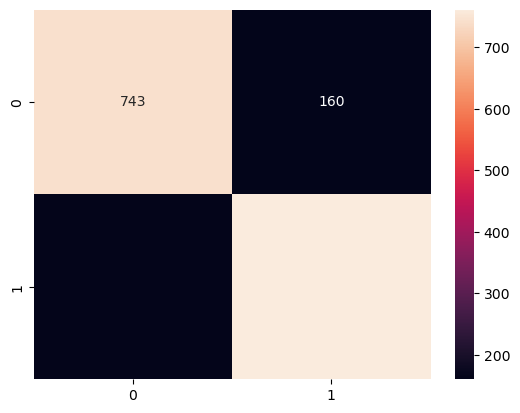

In [26]:
# Calculating and Visualizing the confusion matrix using heatmap
confusion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix,annot=True,fmt="d")

In [27]:
from sklearn.metrics import confusion_matrix
# Define a function to calculate the specificity score
def specificity_score(y_test, y_pred):
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn = cm[0, 0] 
    fp = cm[0, 1]
    return tn / (tn + fp)

In [28]:
# Printing the performance evaluation
accuracy_svm= accuracy_score(y_test, y_pred)
precision_svm = precision_score(y_test, y_pred)
recall_svm = recall_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred)
kappa_svm = cohen_kappa_score(y_test, y_pred)
specificity_svm = specificity_score(y_test, y_pred)
log_loss_svm = log_loss(y_test, y_pred)
roc_auc_score_svm = roc_auc_score(y_test, y_pred)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("Kappa:",kappa_svm)
print("Specificity:", specificity_svm)
print("AUC:", roc_auc_score_svm)
print("Log Loss:", log_loss_svm) 

Accuracy: 0.8227571115973742
Precision: 0.8262757871878393
Recall: 0.8227027027027027
F1 Score: 0.8244853737811484
Kappa: 0.645481546570831
Specificity: 0.82281284606866
AUC: 0.8227577743856813
Log Loss: 6.388481235270217


## Hyperparameter Tuned Classification Algorithm 

### 1. Support Vector Machine (SVM)

In [29]:
# Optimize the parameter grid for hyperparameter tuning
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001], 
			'kernel': ['rbf','linear'],
            } 
model_svm=SVC()
# Set up the GridSearchCV to find the best combination of parameters
grid_search_svm= GridSearchCV(estimator=model_svm, param_grid=param_grid,refit = True, cv=5, n_jobs=-1, verbose=3) 
grid_search_svm.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [30]:
# Printing the  parameters
print(grid_search_svm.best_params_) 
print(grid_search_svm.best_estimator_)

{'C': 10, 'gamma': 1, 'kernel': 'rbf'}
SVC(C=10, gamma=1)


In [31]:
best_svm_model = grid_search_svm.best_estimator_

In [32]:
# Print the classification report
y_pred_svm = grid_search_svm.predict(x_test) 
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       903
           1       0.97      0.94      0.96       925

    accuracy                           0.96      1828
   macro avg       0.96      0.96      0.96      1828
weighted avg       0.96      0.96      0.96      1828



<Axes: >

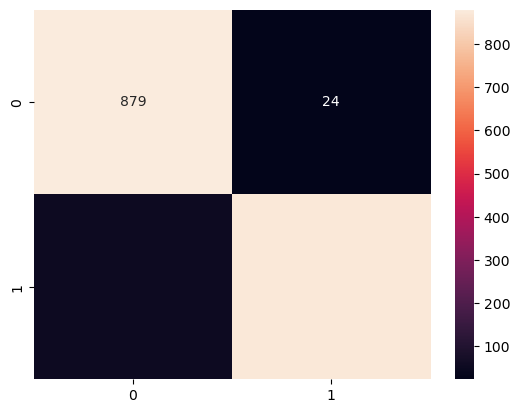

In [33]:
# Calculating and Visualizing the confusion matrix using heatmap
confusion_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(confusion_matrix_svm,annot=True,fmt="d")

In [34]:
from sklearn.metrics import confusion_matrix
# Define a function to calculate the specificity score
def specificity_score(y_test, y_pred_svm):
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred_svm)
    tn = cm[0, 0] 
    fp = cm[0, 1]
    return tn / (tn + fp)

In [35]:
# Printing the performance evaluation
accuracy_svm= accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
kappa_svm = cohen_kappa_score(y_test, y_pred_svm)
specificity_svm = specificity_score(y_test, y_pred_svm)
log_loss_svm = log_loss(y_test, y_pred_svm)
roc_auc_score_svm = roc_auc_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("Kappa:",kappa_svm)
print("Specificity:", specificity_svm)
print("AUC:", roc_auc_score_svm)
print("Log Loss:", log_loss_svm) 

Accuracy: 0.9578774617067833
Precision: 0.9732142857142857
Recall: 0.9427027027027027
F1 Score: 0.9577155409115871
Kappa: 0.9157748858895588
Specificity: 0.973421926910299
AUC: 0.958062314806501
Log Loss: 1.5182501701105147


In [36]:
# Calculating the False Positive Rate (FPR) and True Positive Rate (TPR) for the ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm)
# Calculating the Area Under the Curve (AUC) for the ROC curve
auc_svm = roc_auc_score(y_test, y_pred_svm)

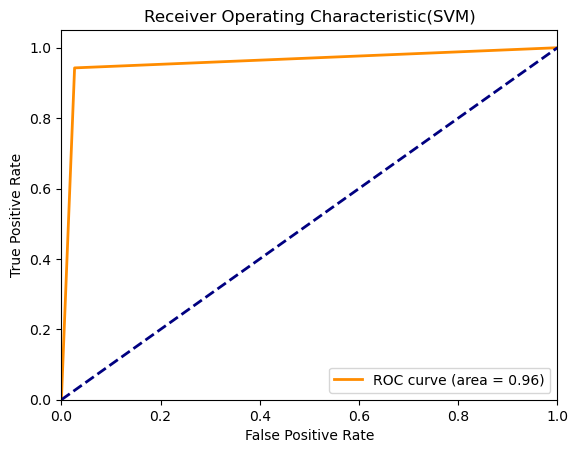

In [37]:
# Plotting the ROC curve with the FPR and TPR values
plt.figure()
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'ROC curve (area = {auc_svm:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic(SVM)')
plt.legend(loc="lower right")
plt.show()

#### Feature Importance (Using Permutation)

In [38]:
# Compute permutation importance
perm_importance= permutation_importance(grid_search_svm, x_test, y_test, n_repeats=30, random_state=42)
importance_df = pd.DataFrame(perm_importance.importances_mean, index=x_resampled.columns, columns=["Importance"])
importance_df = importance_df.sort_values(by="Importance", ascending=False)
# Display the results
print(importance_df)

      Importance
V190    0.238877
V013    0.185248
V024    0.174362
V701    0.137673
V159    0.124307
V201    0.098377
V704    0.097174
V106    0.094238
V025    0.027261
V122    0.019967
V404    0.017670
V161    0.010959


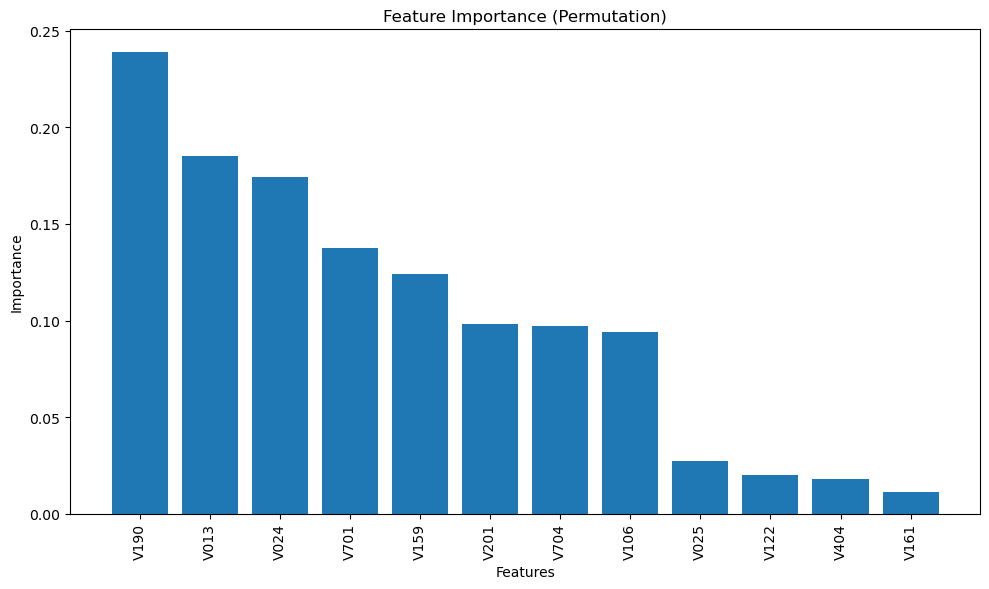

In [39]:
plt.figure(figsize=(10, 6))  
plt.bar(importance_df.index, importance_df['Importance'])
plt.xticks(rotation=90)  
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Permutation)")
plt.tight_layout()
plt.show()

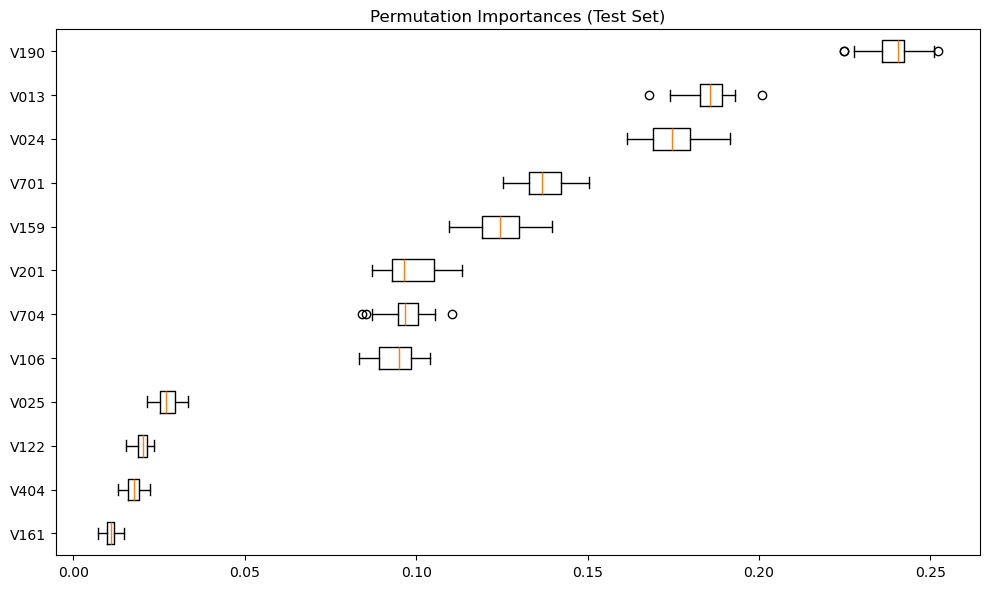

In [40]:
sorted_idx = perm_importance.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(perm_importance.importances[sorted_idx].T, vert=False, labels=x_resampled.columns[sorted_idx])
ax.set_title("Permutation Importances (Test Set)")
fig.tight_layout()
plt.show()

#### Feature Importance (Using SHAP Values)

In [41]:
background_size = 20
background_data = shap.sample(x_train, background_size)
explainer = shap.KernelExplainer(best_svm_model.predict, background_data)

In [42]:
shap_values = explainer.shap_values(x_test, n_jobs=-1)

  0%|          | 0/1828 [00:00<?, ?it/s]

In [43]:
# Calculate mean absolute SHAP value for each feature
feature_importance = np.abs(shap_values).mean(axis=0)
feature_importance

array([0.09717106, 0.07099469, 0.02879629, 0.04611333, 0.06255193,
       0.03894209, 0.02575715, 0.0766322 , 0.0437597 , 0.15842897,
       0.01392332, 0.03052929])

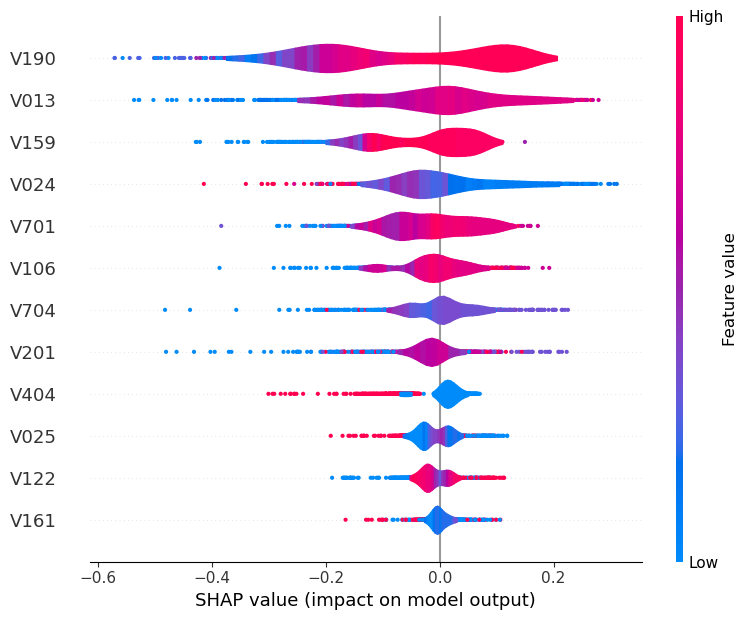

In [44]:
shap.summary_plot(shap_values, x_test, plot_type="violin") 

In [45]:
# SHAP Values as a DataFrame
shap_df = pd.DataFrame(shap_values, columns=x_test.columns)

# Average absolute SHAP value for each feature (overall importance)
overall_importance = np.abs(shap_df).mean(axis=0).sort_values(ascending=False)
print("\nOverall Feature Importance (Average Absolute SHAP Value):")
print(overall_importance)


Overall Feature Importance (Average Absolute SHAP Value):
V190    0.158429
V013    0.097171
V159    0.076632
V024    0.070995
V701    0.062552
V106    0.046113
V704    0.043760
V201    0.038942
V404    0.030529
V025    0.028796
V122    0.025757
V161    0.013923
dtype: float64


In [47]:
shap.initjs()
instance_index = 0

# Force Plot: Shows feature contributions for a single prediction
shap.force_plot(explainer.expected_value, shap_values[instance_index], x_test.iloc[instance_index])

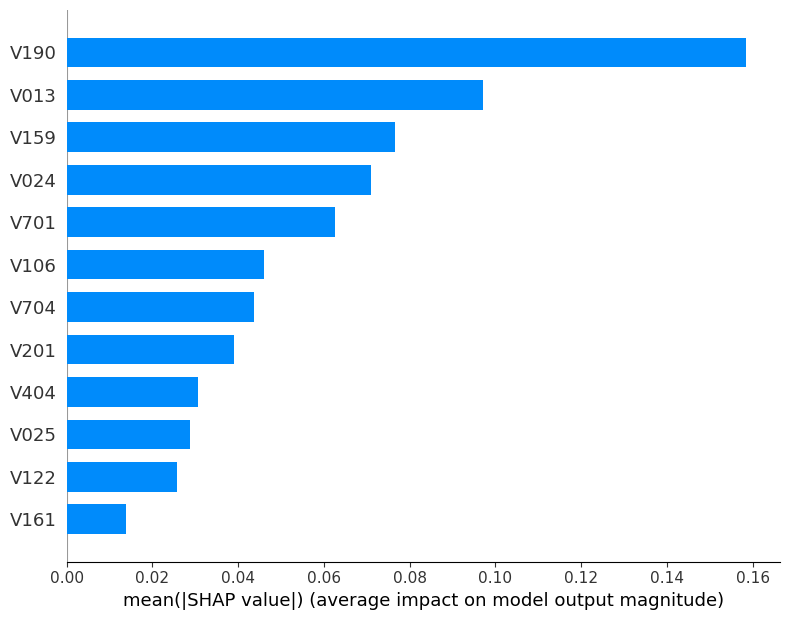

In [51]:
# Bar Plot of Feature Importance
shap.summary_plot(shap_values, x_test, plot_type="bar")
plt.show()

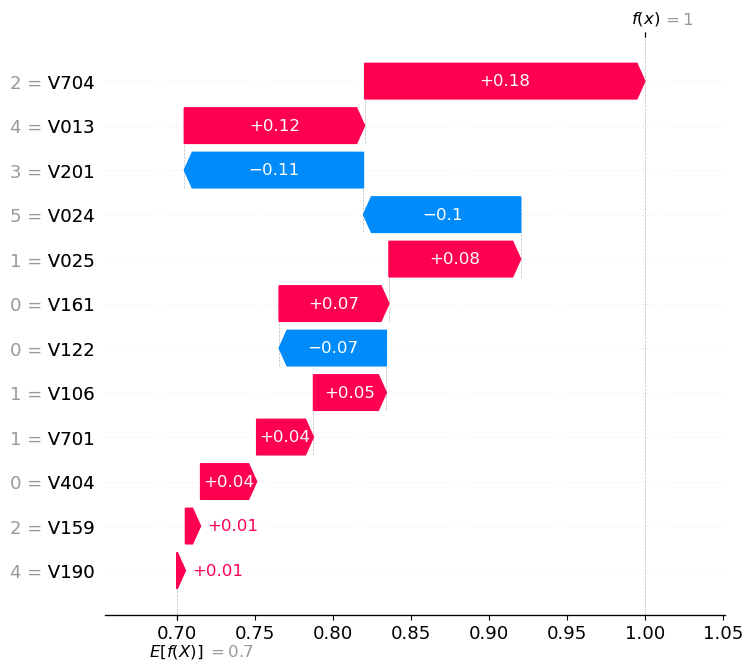

In [52]:
# Select an instance for explanation
instance_index = 0  

# Create SHAP Explanation Object with All Features
shap_explanation = shap.Explanation(
    values=shap_values[instance_index], 
    base_values=explainer.expected_value, 
    data=x_test.iloc[instance_index],
    feature_names=x_test.columns
)

# Generate SHAP Waterfall Plot with ALL Features
shap.waterfall_plot(shap_explanation, max_display=len(x_test.columns))

# Show the plot in Jupyter Notebook
plt.show()